# Clustering Countries Based on AI Workforce Readiness and Automation Levels

This notebook analyzes the **AI Workforce & Automation Dataset (2015–2025)** using **K-Means clustering**.

Goal: to group countries based on similarities in AI investment, automation, employment, productivity, reskilling, 
AI policy, job displacement, job creation, and AI readiness.

This revised version includes improvements:

- Uses the Elbow Method and evaluates **5 clusters**
- Computes **silhouette scores**
- Reports **silhouette scores per cluster**
- Shows cluster sizes and country membership
- Compares cluster differences using summary tables and heatmaps
- Provides improved PCA visualization
- Adds a world map showing country clusters
- Adds automated interpretation outputs

## 1. Importing Libraries

In [142]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import davies_bouldin_score

# Interactive world map
import plotly.express as px

# System settings
import os
import warnings
os.environ["OMP_NUM_THREADS"] = "1"
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

## 2. Loading of the Dataset

In [143]:
# Load dataset
df = pd.read_csv("global_ai_workforce_automation_2015_2025.csv")

# Show the first few rows
df.head().style.hide(axis="index")

Year,Country,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Average_Salary_USD,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score
2015,United States,52.460000,10.750000,65.500000,38392.640000,65.780000,709.030000,0.640000,0.190000,0.140000,47.870000
2016,United States,60.640000,11.640000,65.250000,39371.740000,67.020000,815.380000,0.750000,0.160000,0.850000,43.850000
2017,United States,66.110000,12.460000,64.930000,40772.290000,68.510000,921.740000,0.510000,0.170000,1.230000,37.130000
2018,United States,72.450000,13.350000,64.840000,43974.920000,71.090000,1028.090000,0.690000,0.270000,0.760000,42.280000
2019,United States,79.110000,14.650000,64.550000,43745.390000,69.890000,1134.450000,0.570000,0.250000,0.850000,43.950000


## 3. Inspection of the Dataset

In [144]:
# Check dataset structure, column data types, and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Year                              220 non-null    int64  
 1   Country                           220 non-null    object 
 2   AI_Investment_BillionUSD          220 non-null    float64
 3   Automation_Rate_Percent           220 non-null    float64
 4   Employment_Rate_Percent           220 non-null    float64
 5   Average_Salary_USD                220 non-null    float64
 6   Productivity_Index                220 non-null    float64
 7   Reskilling_Investment_MillionUSD  220 non-null    float64
 8   AI_Policy_Index                   220 non-null    float64
 9   Job_Displacement_Million          220 non-null    float64
 10  Job_Creation_Million              220 non-null    float64
 11  AI_Readiness_Score                220 non-null    float64
dtypes: float

In [145]:
# Check dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 220
Number of columns: 12


In [146]:
# Check missing values per column
df.isnull().sum()

Year                                0
Country                             0
AI_Investment_BillionUSD            0
Automation_Rate_Percent             0
Employment_Rate_Percent             0
Average_Salary_USD                  0
Productivity_Index                  0
Reskilling_Investment_MillionUSD    0
AI_Policy_Index                     0
Job_Displacement_Million            0
Job_Creation_Million                0
AI_Readiness_Score                  0
dtype: int64

In [147]:
# Summary statistics for numeric columns
df.describe()

,Year,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Average_Salary_USD,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score
count,220.000000,220.000000,220.000000,220.000000,220.000000,220.00000,220.000000,220.000000,220.000000,220.000000,220.000000
mean,2020.000000,82.364409,27.352136,68.818909,62074.483818,60.61450,939.959682,0.604500,0.365636,1.247773,43.922318
std,3.169489,42.522535,8.860064,5.833969,19472.117474,11.09393,522.835431,0.164123,0.220901,1.019043,5.581840
min,2015.000000,5.400000,10.190000,57.120000,26787.830000,40.40000,141.240000,0.180000,0.020000,0.030000,32.910000
25%,2017.000000,47.642500,20.337500,63.962500,45251.790000,51.83250,520.207500,0.480000,0.187500,0.430000,39.835000
50%,2020.000000,81.375000,27.085000,68.800000,60828.005000,59.00500,881.575000,0.620000,0.350000,0.935000,42.875000
75%,2023.000000,114.480000,33.812500,73.752500,75538.997500,69.67750,1278.685000,0.722500,0.520000,1.740000,48.072500
max,2025.000000,177.290000,48.410000,79.950000,117335.310000,87.26000,2371.550000,1.000000,1.010000,4.950000,59.100000


## 4. Pre-processing: Aggregate Data by Country and Show Data Visualization and Distribution

The original dataset contains yearly records from 2015 to 2025. Since the goal is to cluster countries, the data is grouped by **Country** and the mean value of each numeric feature is computed.

This means each country is represented by its average AI workforce and automation profile across the full period.
Moreover, this section shows the data visualiztion and distribution of the dataset.

In [148]:
# Group by country and compute average numeric values
df_country = df.groupby("Country").mean(numeric_only=True).reset_index()

# Display country-level dataset
df_country.head()

,Country,Year,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Average_Salary_USD,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score
0,Australia,2020.0,85.682727,33.280000,62.110909,80486.817273,53.221818,772.642727,0.640909,0.388182,1.515455,46.173636
1,Brazil,2020.0,127.274545,34.072727,69.430000,77939.731818,77.448182,1397.200000,0.468182,0.470000,2.270909,47.099091
2,Canada,2020.0,83.683636,25.737273,65.887273,43672.017273,56.115455,1650.230909,0.630000,0.271818,1.196364,43.651818
3,China,2020.0,115.186364,17.590000,66.632727,30396.571818,54.383636,970.934545,0.627273,0.285455,1.830000,39.799091
4,France,2020.0,107.251818,33.815455,75.582727,70418.773636,70.876364,247.172727,0.516364,0.373636,1.491818,45.388182


In [149]:
# Check number of countries after grouping
print("Number of countries:", df_country["Country"].nunique())
print("Shape of country-level dataset:", df_country.shape)

Number of countries: 20
Shape of country-level dataset: (20, 12)


In [150]:
# Creates a statistical summary of the post-aggregated, pre-scaled values
df_country.describe()

,Year,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Average_Salary_USD,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score
count,20.0,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,2020.0,82.364409,27.352136,68.818909,62074.483818,60.614500,939.959682,0.604500,0.365636,1.247773,43.922318
std,0.0,37.527423,8.444539,5.841809,18649.225942,10.413063,450.755255,0.053608,0.095129,0.587958,3.422774
min,2020.0,10.828182,15.231818,59.777273,30396.571818,46.711818,247.172727,0.468182,0.211818,0.209091,37.097273
25%,2020.0,52.155682,21.529545,64.020455,47370.773409,52.599773,573.700227,0.584318,0.271818,0.867727,41.572955
50%,2020.0,87.772727,25.310909,69.265455,61742.210455,57.416364,934.313636,0.611364,0.378182,1.356818,43.906364
75%,2020.0,113.539091,33.843409,74.094773,76341.134773,68.464773,1258.134773,0.637500,0.442955,1.620455,46.252727
max,2020.0,127.775455,43.482727,78.240000,98701.355455,78.415455,1660.082727,0.677273,0.537273,2.270909,51.430000


In [151]:
print(df_country.columns.tolist())

['Country', 'Year', 'AI_Investment_BillionUSD', 'Automation_Rate_Percent', 'Employment_Rate_Percent', 'Average_Salary_USD', 'Productivity_Index', 'Reskilling_Investment_MillionUSD', 'AI_Policy_Index', 'Job_Displacement_Million', 'Job_Creation_Million', 'AI_Readiness_Score']


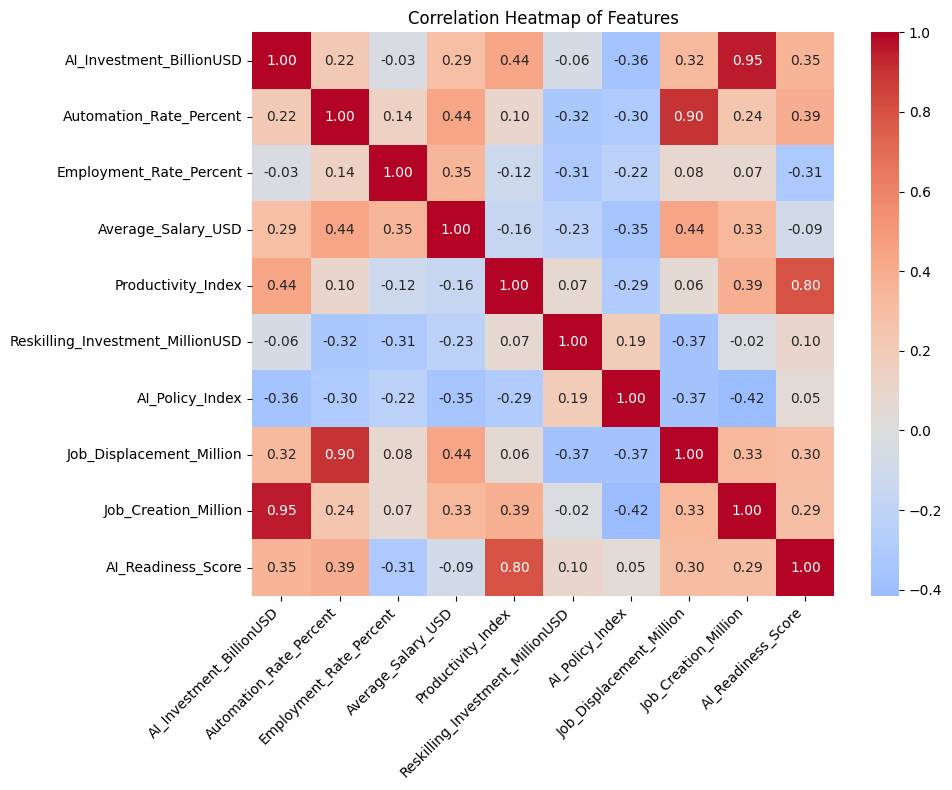

In [152]:
# Correlation heatmap - all numeric features post-aggregation
numeric_cols = df_country.drop(columns=["Country", "Year"])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=300)
plt.show()

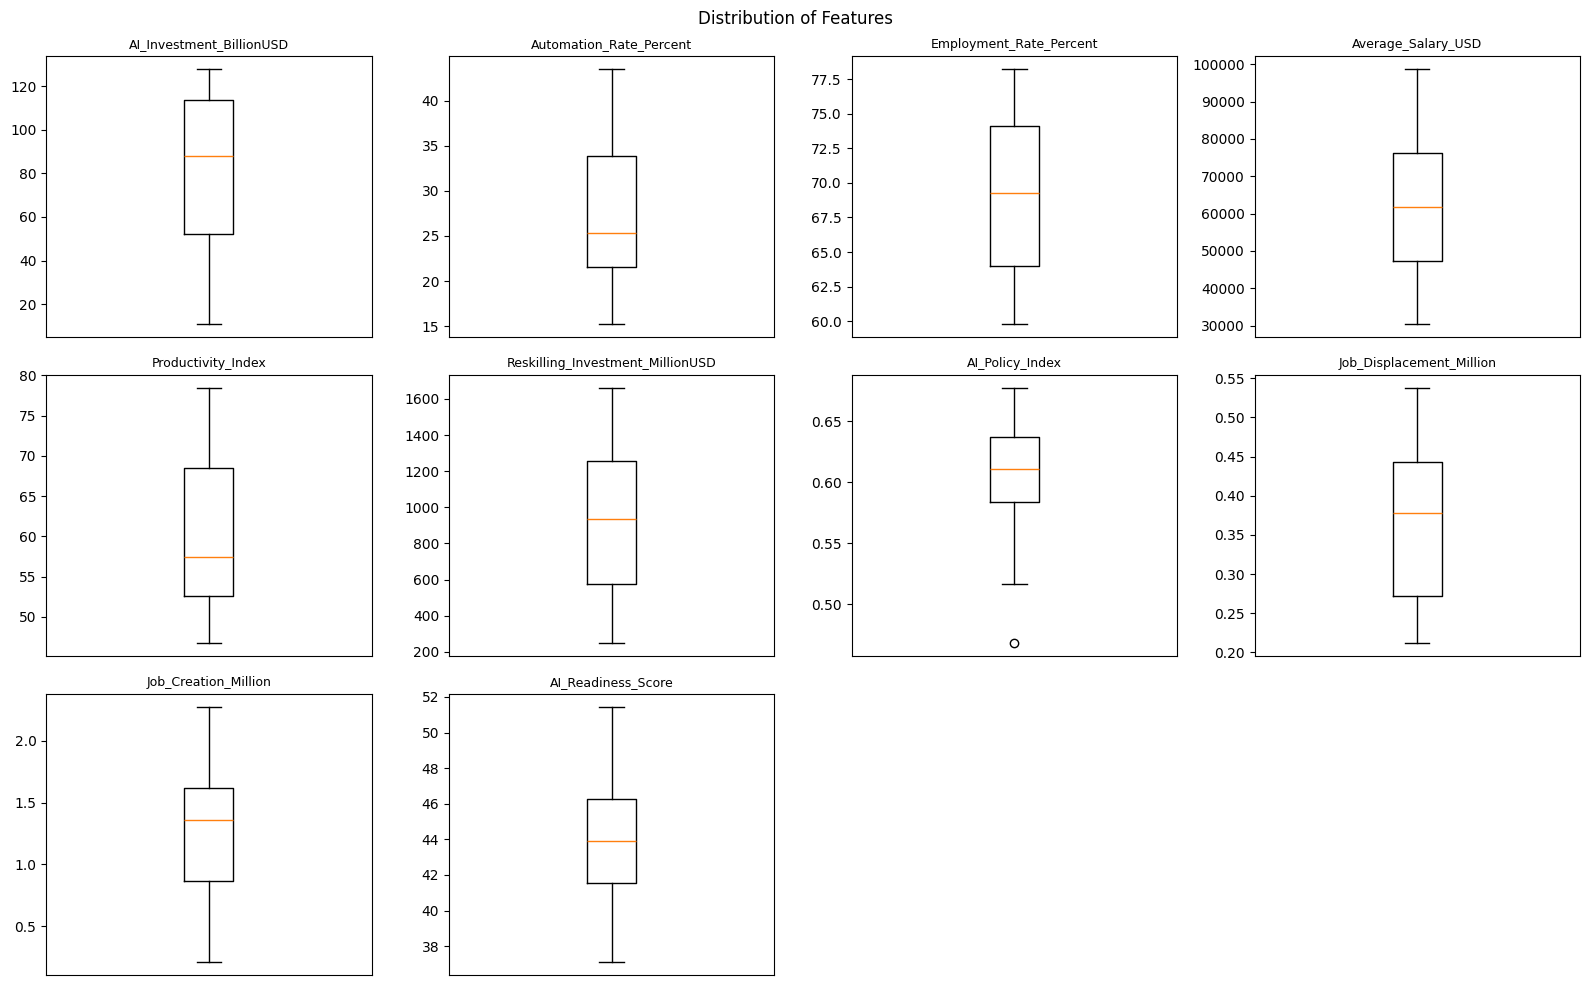

In [153]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols.columns):
    axes[i].boxplot(numeric_cols[col])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xticks([])

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of Features", fontsize=12)
plt.savefig("boxplot.png", dpi=300)
plt.tight_layout()
plt.show()

## 5. Feature Selection

The selected features represent AI adoption, automation, workforce effects, productivity, reskilling, and policy readiness.

In [154]:
features = [
    'AI_Investment_BillionUSD',
    'Automation_Rate_Percent',
    'Employment_Rate_Percent',
    'Productivity_Index',
    'Reskilling_Investment_MillionUSD',
    'AI_Policy_Index',
    'Job_Displacement_Million',
    'Job_Creation_Million',
    'AI_Readiness_Score'
]

# Create feature matrix
X = df_country[features]
X.head()

,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score
0,85.682727,33.280000,62.110909,53.221818,772.642727,0.640909,0.388182,1.515455,46.173636
1,127.274545,34.072727,69.430000,77.448182,1397.200000,0.468182,0.470000,2.270909,47.099091
2,83.683636,25.737273,65.887273,56.115455,1650.230909,0.630000,0.271818,1.196364,43.651818
3,115.186364,17.590000,66.632727,54.383636,970.934545,0.627273,0.285455,1.830000,39.799091
4,107.251818,33.815455,75.582727,70.876364,247.172727,0.516364,0.373636,1.491818,45.388182


## 6. Feature Scaling

K-Means is distance-based, so scaling is important. Without scaling, features with larger numerical ranges, such as reskilling investment, could dominate the clustering result.

In [155]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data to DataFrame for viewing
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.head()

,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score
0,0.090721,0.720212,-1.178105,-0.728386,-0.380835,0.696817,0.243156,0.467101,0.674834
1,1.227818,0.816525,0.107324,1.658589,1.040739,-2.608932,1.125579,1.785359,0.952239
2,0.036067,-0.196200,-0.514874,-0.443282,1.616671,0.488033,-1.011844,-0.089708,-0.081083
3,0.897334,-1.186061,-0.383952,-0.613915,0.070503,0.435837,-0.864774,1.015979,-1.235940
4,0.680408,0.785268,1.187908,1.011081,-1.576874,-1.686802,0.086281,0.425856,0.439393


## 7. Elbow Method and Silhouette Score Evaluation

The Elbow Method checks how inertia changes as the number of clusters increases. Silhouette score checks how well-separated the clusters are.

A higher silhouette score generally indicates better-defined clusters.

In [156]:
evaluation_results = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)
    evaluation_results.append({
        "k": k,
        "Inertia": inertia,
        "Silhouette Score": silhouette
    })

evaluation_df = pd.DataFrame(evaluation_results)
evaluation_df.style.hide(axis="index")

k,Inertia,Silhouette Score
2,128.363660,0.209828
3,107.840827,0.162700
4,89.621487,0.181105
5,78.111517,0.151293
6,66.546982,0.159873
7,62.586746,0.111859
8,52.133768,0.140177
9,42.834518,0.134300
10,35.545221,0.124052


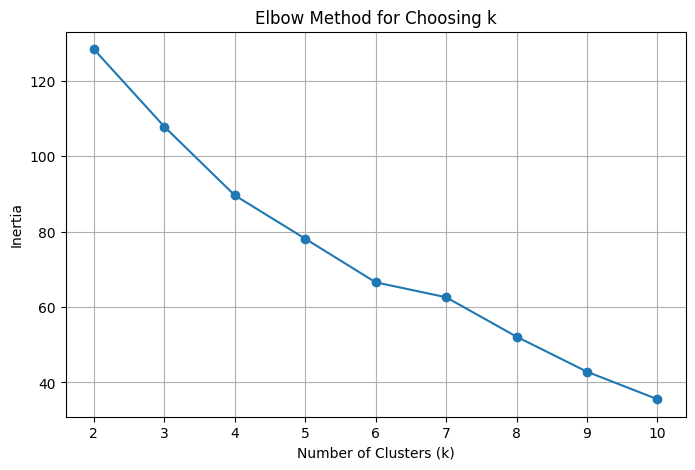

In [157]:
# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(evaluation_df["k"], evaluation_df["Inertia"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing k")
plt.grid(True)
plt.show()

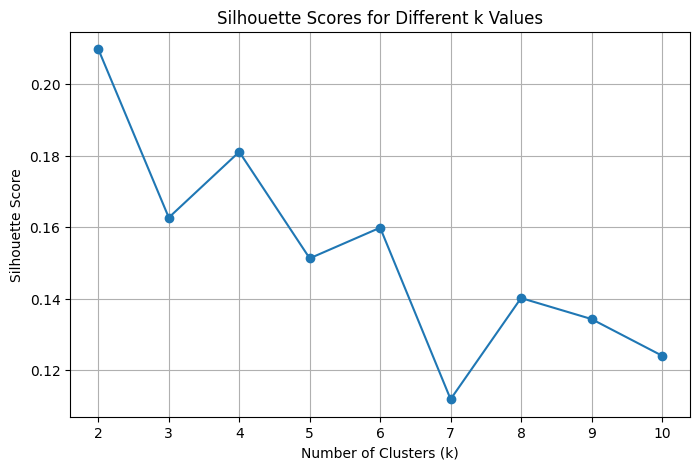

In [158]:
# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(evaluation_df["k"], evaluation_df["Silhouette Score"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different k Values")
plt.grid(True)
plt.show()

## 8. Final K-Means Model Using 5 Clusters

Based on the instructor's recommendation, the final model uses **5 clusters**. Although the silhouette score may be higher for fewer clusters, 5 clusters provide more detailed and interpretable groupings of countries.

In [159]:
# Final K-Means model using 5 clusters
final_k = 5
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df_country["Cluster"] = kmeans.fit_predict(X_scaled)

# Display country and assigned cluster
df_country[["Country", "Cluster"]].sort_values("Cluster").style.hide(axis="index")

Country,Cluster
Turkey,0
China,0
Spain,0
Germany,0
United States,1
Brazil,1
Japan,1
Netherlands,1
South Korea,2
South Africa,2


## 9. Cluster Sizes

This checks how many countries belong to each cluster. Since the dataset has only 20 countries, using 5 clusters may produce small groups.

In [160]:
cluster_sizes = df_country["Cluster"].value_counts().sort_index()
cluster_sizes_df = cluster_sizes.reset_index()
cluster_sizes_df.columns = ["Cluster", "Number of Countries"]
cluster_sizes_df.style.hide(axis="index")

Cluster,Number of Countries
0,4
1,4
2,4
3,4
4,4


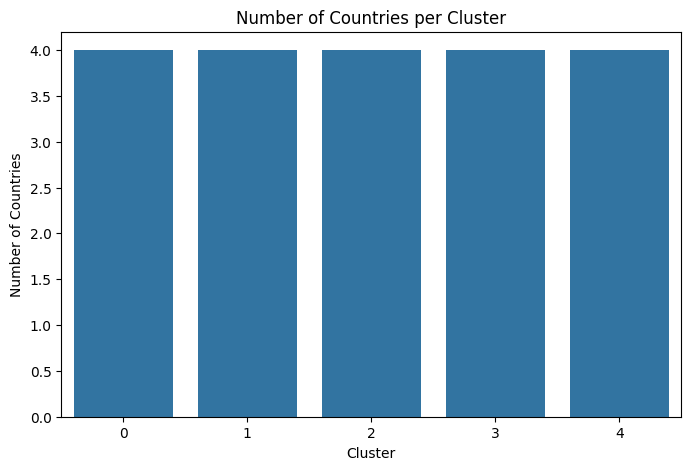

In [161]:
plt.figure(figsize=(8, 5))
sns.barplot(data=cluster_sizes_df, x="Cluster", y="Number of Countries")
plt.title("Number of Countries per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Countries")
plt.show()

## 10. Countries in Each Cluster

In [162]:
countries_per_cluster = df_country.groupby("Cluster")["Country"].apply(list)
countries_per_cluster

Cluster
0                  [China, Germany, Spain, Turkey]
1      [Brazil, Japan, Netherlands, United States]
2      [France, Mexico, South Africa, South Korea]
3    [Australia, Italy, Singapore, United Kingdom]
4                  [Canada, India, Russia, Sweden]
Name: Country, dtype: object

## 11. Cluster Mean Profiles

The table below shows the average feature values of each cluster. This helps explain how clusters differ from one another.

In [163]:
cluster_profile = df_country.groupby("Cluster")[features].mean()
cluster_profile.loc["Overall Mean"] = df_country[features].mean()
cluster_profile.round(3)

,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score
Cluster,,,,,,,,,
0,101.014,21.303,74.290,52.402,737.540,0.606,0.327,1.632,39.839
1,112.032,24.812,66.128,76.191,1165.390,0.582,0.359,1.666,47.962
2,98.076,38.746,71.066,65.690,540.934,0.570,0.467,1.479,45.653
3,58.088,30.678,64.861,50.802,755.314,0.625,0.415,0.804,43.201
4,42.611,21.222,67.749,57.989,1500.620,0.639,0.261,0.659,42.956
Overall Mean,82.364,27.352,68.819,60.614,939.960,0.604,0.366,1.248,43.922


## 12. Standardized Cluster Profile

The standardized profile is useful because it shows whether a cluster is above or below the overall average for each feature.

Positive values mean the cluster is above average. Negative values mean the cluster is below average.

In [164]:
scaled_country_df = pd.DataFrame(X_scaled, columns=features)
scaled_country_df["Country"] = df_country["Country"]
scaled_country_df["Cluster"] = df_country["Cluster"]

standardized_cluster_profile = scaled_country_df.groupby("Cluster")[features].mean()
standardized_cluster_profile.round(2)

,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score
Cluster,,,,,,,,,
0,0.51,-0.73,0.96,-0.81,-0.46,0.02,-0.41,0.67,-1.22
1,0.81,-0.31,-0.47,1.53,0.51,-0.42,-0.07,0.73,1.21
2,0.43,1.38,0.39,0.50,-0.91,-0.66,1.09,0.40,0.52
3,-0.66,0.40,-0.70,-0.97,-0.42,0.39,0.53,-0.77,-0.22
4,-1.09,-0.74,-0.19,-0.26,1.28,0.66,-1.13,-1.03,-0.29


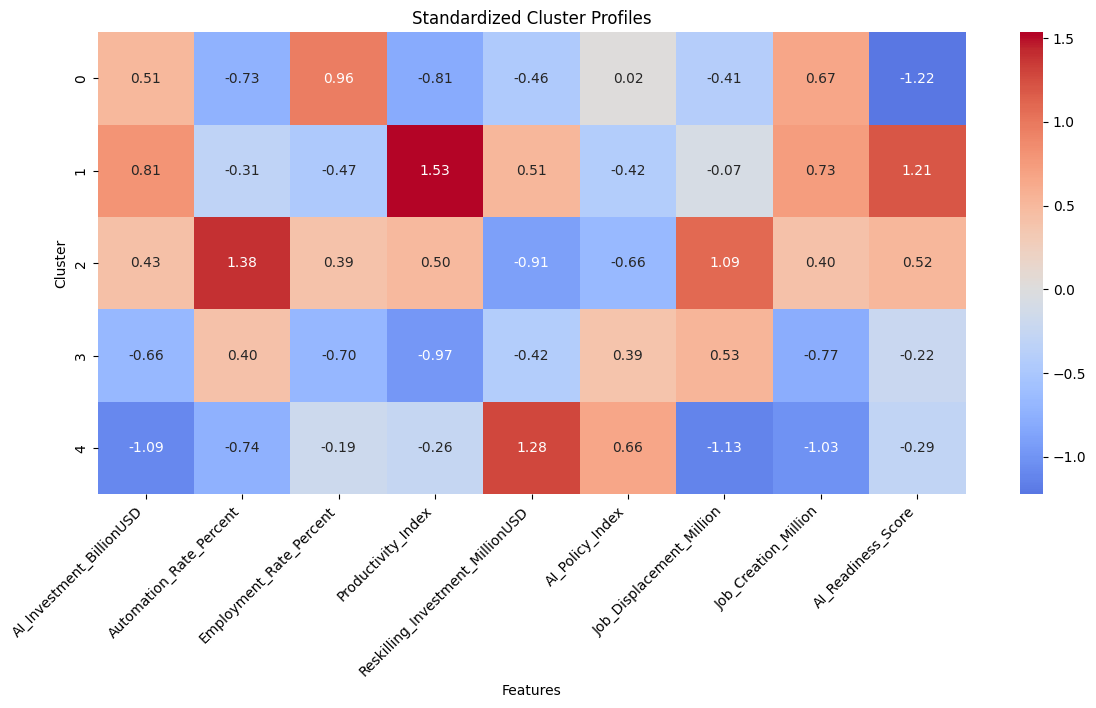

In [165]:
plt.figure(figsize=(14, 6))
sns.heatmap(standardized_cluster_profile, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Standardized Cluster Profiles")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.xticks(rotation=45, ha="right")
plt.show()

## 13. Performance Metrics

This checks which clusters are more well-separated and interpretable. A higher silhouette value means the countries in that cluster are more similar to each other and more distinct from other clusters.

In [166]:
# Overall silhouette score for the final model
overall_silhouette = silhouette_score(X_scaled, df_country["Cluster"])
print("Overall Silhouette Score for k=5:", round(overall_silhouette, 3))

Overall Silhouette Score for k=5: 0.151


In [167]:
# Silhouette score for each country
sample_silhouette_values = silhouette_samples(X_scaled, df_country["Cluster"])
df_country["Silhouette_Score"] = sample_silhouette_values

# Average silhouette score per cluster
silhouette_per_cluster = df_country.groupby("Cluster")["Silhouette_Score"].agg(["mean", "min", "max", "count"])
silhouette_per_cluster.round(3)

,mean,min,max,count
Cluster,,,,
0,0.111,0.020,0.231,4
1,-0.032,-0.202,0.182,4
2,0.207,0.133,0.314,4
3,0.210,0.114,0.319,4
4,0.261,0.182,0.359,4


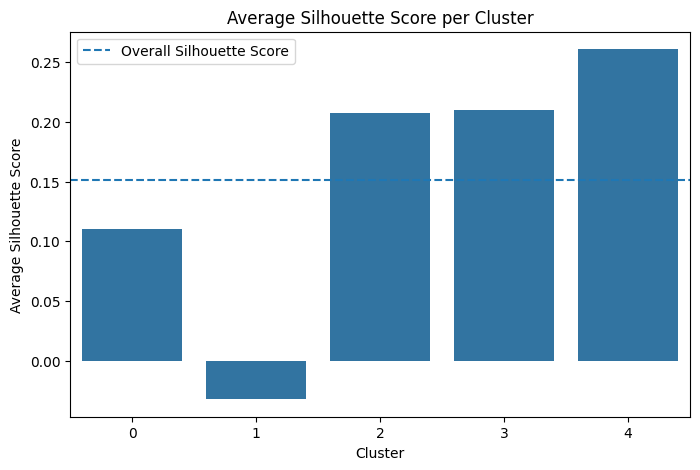

In [168]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=silhouette_per_cluster.reset_index(),
    x="Cluster",
    y="mean"
)
plt.axhline(overall_silhouette, linestyle="--", label="Overall Silhouette Score")
plt.title("Average Silhouette Score per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Silhouette Score")
plt.legend()
plt.show()

In [169]:
db_score = davies_bouldin_score(X_scaled, df_country["Cluster"])
print("Davies-Bouldin Index:", round(db_score, 3))

Davies-Bouldin Index: 1.277


In [170]:
from scipy.spatial.distance import cdist
import numpy as np

def dunns_index(X, labels):
    clusters = np.unique(labels)
    
    # Minimum inter-cluster distance (separation)
    inter_cluster_distances = []
    for i in clusters:
        for j in clusters:
            if i >= j:
                continue
            points_i = X[labels == i]
            points_j = X[labels == j]
            dist = cdist(points_i, points_j).min()
            inter_cluster_distances.append(dist)
    
    # Maximum intra-cluster diameter (compactness)
    intra_cluster_diameters = []
    for i in clusters:
        points_i = X[labels == i]
        if len(points_i) > 1:
            diameter = cdist(points_i, points_i).max()
        else:
            diameter = 0
        intra_cluster_diameters.append(diameter)
    
    dunn = min(inter_cluster_distances) / max(intra_cluster_diameters)
    return dunn

# Compute Dunn's Index
labels = df_country["Cluster"].values
dunn = dunns_index(X_scaled, labels)
print("Dunn's Index:", round(dunn, 3))

Dunn's Index: 0.453


In [171]:
print("Overall Silhouette Score:", round(overall_silhouette, 3))
print("Davies-Bouldin Index:    ", round(db_score, 3))
print("Dunn's Index:            ", round(dunn, 3))

Overall Silhouette Score: 0.151
Davies-Bouldin Index:     1.277
Dunn's Index:             0.453


## 14. Descriptive Cluster Labels

The cluster labels below are based on the observed differences in the cluster profiles.

In [172]:
cluster_labels = {
    0: "Employment-strong, lower-readiness",
    1: "High-investment, high-readiness",
    2: "Automation-heavy transition",
    3: "Mid-level automation, lower gains",
    4: "Policy- and reskilling-focused"
}

df_country["Cluster_Label"] = df_country["Cluster"].map(cluster_labels)

df_country[["Country", "Cluster", "Cluster_Label", "Silhouette_Score"]].sort_values("Cluster")

,Country,Cluster,Cluster_Label,Silhouette_Score
17,Turkey,0,"Employment-strong, lower-readiness",0.058205
3,China,0,"Employment-strong, lower-readiness",0.133666
15,Spain,0,"Employment-strong, lower-readiness",0.019651
5,Germany,0,"Employment-strong, lower-readiness",0.231010
19,United States,1,"High-investment, high-readiness",-0.202424
1,Brazil,1,"High-investment, high-readiness",-0.130019
8,Japan,1,"High-investment, high-readiness",0.181849
10,Netherlands,1,"High-investment, high-readiness",0.021331
14,South Korea,2,Automation-heavy transition,0.132951
13,South Africa,2,Automation-heavy transition,0.153379


## 15. PCA Visualization of Clusters

PCA reduces the selected features into two components for visualization. The actual K-Means clustering still used all selected features, not only the two PCA components.

In [173]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(kmeans.cluster_centers_)

df_country["PCA1"] = components[:, 0]
df_country["PCA2"] = components[:, 1]

explained_variance = pca.explained_variance_ratio_
print("Explained variance by PCA 1:", round(explained_variance[0], 3))
print("Explained variance by PCA 2:", round(explained_variance[1], 3))
print("Total explained variance:", round(explained_variance.sum(), 3))

Explained variance by PCA 1: 0.367
Explained variance by PCA 2: 0.221
Total explained variance: 0.587


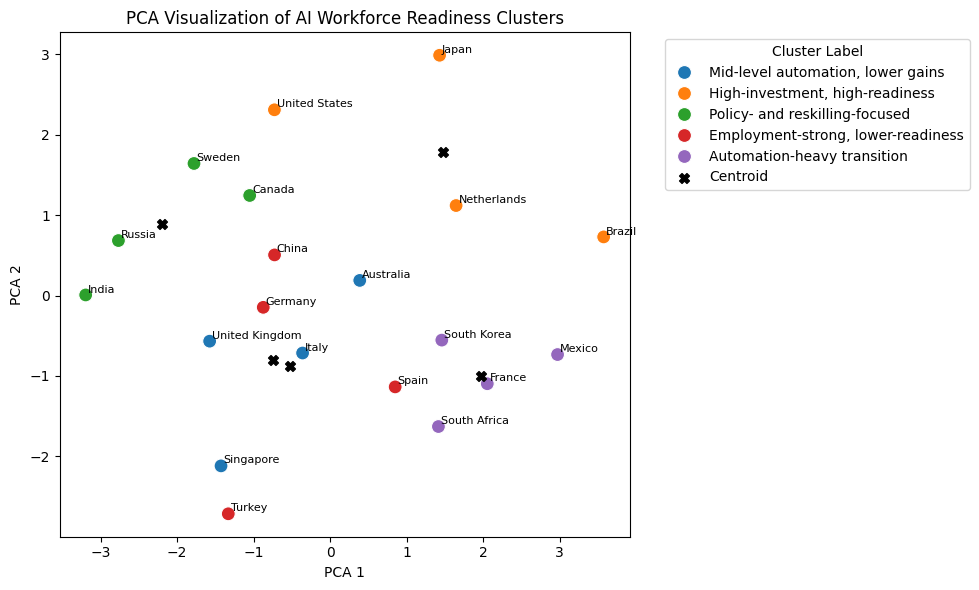

In [175]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_country,
    x="PCA1",
    y="PCA2",
    hue="Cluster_Label",
    s=100
)

plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    c='black',
    marker='X',
    s=50,
    label='Centroid'
)

# Add country labels
for _, row in df_country.iterrows():
    plt.text(row["PCA1"] + 0.03, row["PCA2"] + 0.03, row["Country"], fontsize=8)

plt.title("PCA Visualization of AI Workforce Readiness Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster Label", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.savefig("pca-with-centroid.png", dpi=300)
plt.tight_layout()
plt.show()

## 16. World Map of Country Clusters

This visualization colors countries based on their assigned cluster.

In [ ]:
fig = px.choropleth(
    df_country,
    locations="Country",
    locationmode="country names",
    color="Cluster_Label",
    hover_name="Country",
    hover_data=["Cluster", "AI_Readiness_Score", "Automation_Rate_Percent", "Productivity_Index"],
    title="World Map of AI Workforce Readiness Clusters"
)

fig.show()

## 17. Automated Cluster Interpretation

The output below automatically prints the countries and strongest characteristics of each cluster using standardized feature values.

In [ ]:
for cluster_id in sorted(df_country["Cluster"].unique()):
    print("=" * 80)
    print(f"Cluster {cluster_id}: {cluster_labels[cluster_id]}")
    print("Countries:", ", ".join(df_country[df_country["Cluster"] == cluster_id]["Country"].tolist()))
    print()
    
    profile = standardized_cluster_profile.loc[cluster_id].sort_values(ascending=False)
    print("Highest above-average features:")
    print(profile.head(3).round(2))
    print()
    print("Lowest below-average features:")
    print(profile.tail(3).round(2))
    print()

## 18. Final Summary

The final K-Means model used **5 clusters** to group countries according to their average AI workforce and automation indicators from 2015 to 2025. The 5-cluster solution gives more detailed country groupings, but because there are only 20 countries, each cluster is small.

The silhouette score analysis shows that some clusters are more distinct and interpretable than others. The cluster profile table and heatmap help explain the differences among the groups, while the PCA plot and world map improve visualization of the results.

Overall, the model shows that countries differ not only in AI investment and automation levels, but also in workforce readiness, productivity, policy support, reskilling investment, job displacement, and job creation.